# Netflix Customer Churn & Engagement Analysis

## 📌 Context & Business Problem

Customer churn (subscriber attrition) is one of the most critical challenges facing global streaming platforms. Acquiring a new customer often costs 5 to 7 times more than retaining an existing one.

This dataset tracks user engagement, hardware utilization, billing mechanisms, and account inactivity to help data scientists and analysts uncover:

1. **Early Attrition Indicators**: What behavioral signals (e.g., login inactivity, declining watch hours) predict churn before it happens?
2. **Subscription Tier Viability**: How do churn rates differ between Basic ($8.99), Standard ($13.99), and Premium ($17.99) plans?
3. **Regional & Demographic Dynamics**: Which geographic markets and age cohorts represent the highest retention or attrition risk?
4. **Payment Gateway Friction**: Does payment method (e.g., Crypto, Gift Card vs Credit/Debit) impact customer lifetime value?

## 💡 Potential Tasks & Challenges for Kaggle Users
1. **Supervised Classification:**
    - Build and compare models (Logistic Regression, Random Forest, XGBoost, CatBoost, LightGBM) to classify subscriber churn (ROC-AUC, F1-Score, Precision-Recall).
2. **Feature Importance & Interpretability:**
    - Use SHAP (SHapley Additive exPlanations) to identify the driving factors behind churn decisions.
3. **Customer Segmentation & Clustering:**
    - Perform unsupervised clustering (K-Means, DBSCAN) using watch hours, daily streaming duration, and profile counts to identify distinct subscriber personas (e.g. "Binge Watchers", "Casual Viewers", "Dormant Accounts").
4. **Interactive Dashboarding:**
    - Explore and run the included Streamlit analytics app (streamlit_app.py) featuring full Power BI-style dark UX.

**Resolve all business problems and complete all tasks & challenges**

#### Import necessary libraries

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_theme()
%matplotlib inline

#### Load the dataset

In [79]:
path = "data/netflix_customer_churn.csv"
df = pd.read_csv(path)

#### Take a quick look at the Data

In [80]:
# First 10 rows of the data
df.head(10)

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action
5,d8079475-5be7-47e9-8782-ceb7ff61395e,58,Female,Standard,13.80,26,Oceania,Mobile,13.99,0,Debit Card,3,0.51,Action
6,8e63450a-13d6-4e83-bbb5-6aebde9152cb,48,Other,Basic,13.83,20,Asia,TV,8.99,0,Gift Card,5,0.66,Romance
7,02387681-8c42-462a-807a-de0168c73b38,51,Male,Basic,14.30,56,Europe,Mobile,8.99,1,Gift Card,1,0.25,Action
8,0bcaad0c-545c-4ee1-85a6-75e165f39361,45,Other,Basic,9.98,10,Asia,Mobile,8.99,0,PayPal,3,0.91,Romance
9,eae6439e-8cdf-4258-ab49-c493925b927a,32,Other,Premium,2.22,34,Europe,TV,17.99,1,Debit Card,1,0.06,Drama


In [81]:
# Last 10 rows of the data
df.tail(10)

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
4990,edb9036d-95f9-4998-9910-78ba85869dbd,57,Male,Standard,2.09,13,Asia,TV,13.99,1,Crypto,3,0.15,Romance
4991,ac6eb271-0239-4957-b828-c89508fcfbea,62,Male,Standard,7.31,26,Oceania,Desktop,13.99,0,Credit Card,2,0.27,Sci-Fi
4992,9721209e-3147-456f-a2c0-81d23b4cf822,34,Male,Standard,10.25,41,Oceania,Desktop,13.99,1,Crypto,3,0.24,Documentary
4993,f915a366-31c7-4a9e-9042-ca526c771219,23,Other,Standard,3.10,12,Europe,Laptop,13.99,1,Crypto,5,0.24,Comedy
4994,75532a22-9cd9-492c-8865-fa4ac7da2ec8,58,Other,Basic,10.90,22,Europe,TV,8.99,0,Credit Card,3,0.47,Action
4995,44f3ba44-b95d-4e50-a786-bac4d06f4a43,19,Female,Basic,49.17,11,Europe,Desktop,8.99,0,Credit Card,4,4.10,Drama
4996,18779bcb-ba2b-41da-b751-e70b812061ec,67,Female,Basic,9.24,2,North America,Desktop,8.99,0,PayPal,3,3.08,Documentary
4997,3f32e8c5-615b-4a3b-a864-db2688f7834f,66,Male,Standard,16.55,49,South America,Desktop,13.99,1,Debit Card,2,0.33,Action
4998,7b0ad82d-6571-430e-90f4-906259e0e89c,59,Female,Basic,9.12,3,Europe,Laptop,8.99,0,Credit Card,4,2.28,Sci-Fi
4999,82aeef39-ddb0-40ad-bae1-5c436e0cf042,57,Male,Basic,1.62,17,Africa,Mobile,8.99,1,Crypto,2,0.09,Action


In [82]:
# Information of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

In [83]:
df['gender'].value_counts()

gender
Female    1711
Male      1654
Other     1635
Name: count, dtype: int64

In [84]:
df['subscription_type'].value_counts()

subscription_type
Premium     1693
Basic       1661
Standard    1646
Name: count, dtype: int64

In [85]:
df['region'].value_counts()

region
South America    873
Europe           867
North America    851
Asia             841
Africa           803
Oceania          765
Name: count, dtype: int64

In [86]:
df['device'].value_counts()

device
Tablet     1048
Laptop     1006
Mobile     1004
TV          993
Desktop     949
Name: count, dtype: int64

In [87]:
df['churned'].value_counts()

churned
1    2515
0    2485
Name: count, dtype: int64

In [88]:
df['payment_method'].value_counts()

payment_method
Debit Card     1030
PayPal         1026
Crypto          995
Gift Card       976
Credit Card     973
Name: count, dtype: int64

In [89]:
df['favorite_genre'].value_counts()

favorite_genre
Drama          731
Documentary    729
Romance        725
Sci-Fi         720
Horror         713
Action         697
Comedy         685
Name: count, dtype: int64

In [90]:
# Description of the data
df.describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649450,30.089800,13.683400,0.503000,3.024400,0.874800
std,15.501128,12.014654,17.536078,3.692062,0.500041,1.415841,2.619824
min,18.000000,0.010000,0.000000,8.990000,0.000000,1.000000,0.000000
25%,30.000000,3.337500,15.000000,8.990000,0.000000,2.000000,0.110000
50%,44.000000,8.000000,30.000000,13.990000,1.000000,3.000000,0.290000
75%,58.000000,16.030000,45.000000,17.990000,1.000000,4.000000,0.720000
max,70.000000,110.400000,60.000000,17.990000,1.000000,5.000000,98.420000


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'watch_hours'}>,
        <Axes: title={'center': 'last_login_days'}>],
       [<Axes: title={'center': 'monthly_fee'}>,
        <Axes: title={'center': 'churned'}>,
        <Axes: title={'center': 'number_of_profiles'}>],
       [<Axes: title={'center': 'avg_watch_time_per_day'}>, <Axes: >,
        <Axes: >]], dtype=object)

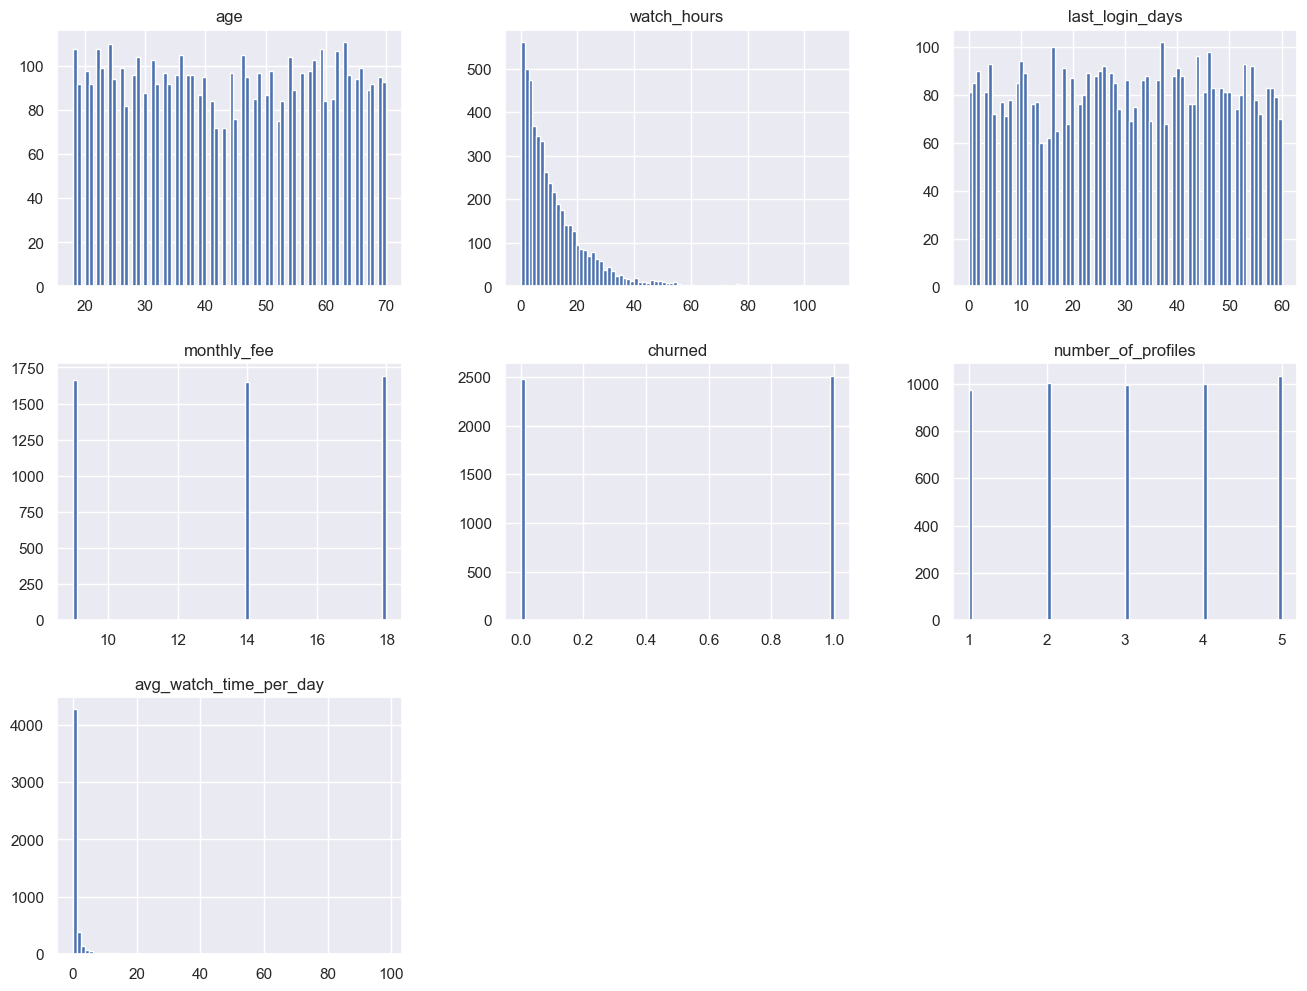

In [91]:
# Hist plot of the numerical features
df.hist(bins=80, figsize=(16,12))

#### 🔍 Initial Data Takeaways

Taking a quick look at the dataset, each row represents an individual user.

* **Target Variable:** `churned`
* **Numerical Features:** `age`, `watch_hours`, `last_login_days`, `number_of_profiles`, `avg_watch_time_per_day`
* **Categorical Features:** `gender`, `subscription_type`, `region`, `device`, `monthly_fee`, `payment_method`, `favorite_genre`
  > *Heads-up:* `subscription_type` and `monthly_fee` carry redundant information (they map 1:1).

---

#### Key Observations:
- **Missing Data:** Clean across the board—no null values to deal with.
- **Categorical Balance:** Classes are surprisingly well-balanced across categories (e.g., `gender` splits almost evenly: ~1,711 Female, ~1,654 Male, ~1,635 Other).
- **Distributions from Histograms:**
  - **Uniform:** `age`, `last_login_days`, and `number_of_profiles` show fairly flat/uniform distributions.
  - **Right-Skewed:** `watch_hours` and `avg_watch_time_per_day` have long tails to the right, which makes sense—most users watch moderately, while a small group clocks high hours.


#### Split the test set

In [92]:
# Structural Drop: `customer_id` and `monthly_fee`
X = df.drop(columns=['customer_id', 'monthly_fee'])
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42, test_size=0.2)

Comparing `watch_hours` and `avg_watch_time_per_day` across the train and test sets. 

Because of the heavy right skew, we want to make sure the split didn't create an imbalance—our training set needs to stay representative of the overall distribution.

In [93]:
# Compare the `watch_hours` distribution
print("Train watch_hours:\n", X_train['watch_hours'].describe())
print("\nTest watch_hours:\n", X_test['watch_hours'].describe())

# Statistical test — check the distribution is the same or not
from scipy.stats import ks_2samp
stat, p_value = ks_2samp(X_train['watch_hours'], X_test['watch_hours'])
print(f"KS-test p-value: {p_value}")
# If p-value > 0.05 → distribution is the same (there is no significant difference)

Train watch_hours:
 count    4000.000000
mean       11.590895
std        11.780691
min         0.010000
25%         3.360000
50%         8.075000
75%        16.052500
max       101.060000
Name: watch_hours, dtype: float64

Test watch_hours:
 count    1000.000000
mean       11.883670
std        12.911751
min         0.050000
25%         3.160000
50%         7.640000
75%        15.880000
max       110.400000
Name: watch_hours, dtype: float64
KS-test p-value: 0.5749011372347846


In [94]:
# Apply the same to `avg_watch_time_per_day`
# Compare the `avg_watch_time_per_day` distribution
print("Train avg_watch_time_per_day:\n", X_train['avg_watch_time_per_day'].describe())
print("\nTest avg_watch_time_per_day:\n", X_test['avg_watch_time_per_day'].describe())

# Statistical test — check the distribution is the same or not
from scipy.stats import ks_2samp
stat, p_value = ks_2samp(X_train['avg_watch_time_per_day'], X_test['avg_watch_time_per_day'])
print(f"KS-test p-value: {p_value}")
# If p-value > 0.05 → distribution is the same (there is no significant difference)

Train avg_watch_time_per_day:
 count    4000.000000
mean        0.882547
std         2.742768
min         0.000000
25%         0.110000
50%         0.300000
75%         0.720000
max        98.420000
Name: avg_watch_time_per_day, dtype: float64

Test avg_watch_time_per_day:
 count    1000.00000
mean        0.84381
std         2.05669
min         0.00000
25%         0.11000
50%         0.28000
75%         0.71250
max        34.53000
Name: avg_watch_time_per_day, dtype: float64
KS-test p-value: 0.39066721123699827


`avg_watch_time_per_day` isn't distributed fairly between training set and test set. It needs to be fixed.

In [98]:
# 1. Create quantile bins on the skewed feature
# duplicates='drop' handles cases where quantile edges collide (common with skewed/zero-heavy data)
watch_time_bin = pd.qcut(df['avg_watch_time_per_day'], q=5, duplicates='drop')
watch_hours_bin = pd.qcut(df['watch_hours'], q=5, duplicates='drop')

# 2. Combine with the churn label into one stratification key
strat_key = df['churned'].astype(str) + "_" + watch_time_bin.astype(str) + "_" + watch_hours_bin.astype(str)

# 3. Check every stratum has enough members for a 0.2 test split
print(strat_key.value_counts())

# 4. Split using the combined key
X = df.drop(columns=['customer_id', 'monthly_fee'])
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=strat_key, random_state=42, test_size=0.2
)

1_(-0.001, 0.09]_(0.009000000000000001, 2.578]    730
0_(0.91, 98.42]_(18.514, 110.4]                   503
0_(0.41, 0.91]_(18.514, 110.4]                    378
1_(0.09, 0.21]_(2.578, 5.94]                      343
1_(0.21, 0.41]_(10.54, 18.514]                    329
1_(0.09, 0.21]_(5.94, 10.54]                      322
1_(-0.001, 0.09]_(2.578, 5.94]                    288
0_(0.41, 0.91]_(10.54, 18.514]                    258
0_(0.91, 98.42]_(10.54, 18.514]                   244
0_(0.21, 0.41]_(5.94, 10.54]                      185
0_(0.41, 0.91]_(5.94, 10.54]                      162
0_(0.91, 98.42]_(5.94, 10.54]                     143
1_(0.21, 0.41]_(5.94, 10.54]                      114
1_(0.09, 0.21]_(0.009000000000000001, 2.578]       90
0_(0.21, 0.41]_(10.54, 18.514]                     84
0_(0.09, 0.21]_(2.578, 5.94]                       77
1_(0.21, 0.41]_(2.578, 5.94]                       74
0_(0.91, 98.42]_(2.578, 5.94]                      73
0_(0.09, 0.21]_(5.94, 10.54]

Now, let's test again.

In [99]:
# Compare the `avg_watch_time_per_day` distribution
print("Train avg_watch_time_per_day:\n", X_train['avg_watch_time_per_day'].describe())
print("\nTest avg_watch_time_per_day:\n", X_test['avg_watch_time_per_day'].describe())

# Statistical test — check the distribution is the same or not
from scipy.stats import ks_2samp
stat, p_value = ks_2samp(X_train['avg_watch_time_per_day'], X_test['avg_watch_time_per_day'])
print(f"KS-test p-value: {p_value}")
# If p-value > 0.05 → distribution is the same (there is no significant difference)

Train avg_watch_time_per_day:
 count    4000.000000
mean        0.891062
std         2.709301
min         0.000000
25%         0.110000
50%         0.290000
75%         0.720000
max        98.420000
Name: avg_watch_time_per_day, dtype: float64

Test avg_watch_time_per_day:
 count    1000.000000
mean        0.809750
std         2.226273
min         0.000000
25%         0.110000
50%         0.295000
75%         0.720000
max        34.530000
Name: avg_watch_time_per_day, dtype: float64
KS-test p-value: 0.9382099707716749


In [100]:
# Compare the `watch_hours` distribution
print("Train watch_hours:\n", X_train['watch_hours'].describe())
print("\nTest watch_hours:\n", X_test['watch_hours'].describe())

# Statistical test — check the distribution is the same or not
from scipy.stats import ks_2samp
stat, p_value = ks_2samp(X_train['watch_hours'], X_test['watch_hours'])
print(f"KS-test p-value: {p_value}")
# If p-value > 0.05 → distribution is the same (there is no significant difference)

Train watch_hours:
 count    4000.000000
mean       11.630010
std        12.014596
min         0.010000
25%         3.310000
50%         8.020000
75%        15.970000
max       110.400000
Name: watch_hours, dtype: float64

Test watch_hours:
 count    1000.000000
mean       11.727210
std        12.020583
min         0.010000
25%         3.405000
50%         7.890000
75%        16.140000
max        79.830000
Name: watch_hours, dtype: float64
KS-test p-value: 0.7405401516830782


#### Exploratory Data Analysis (EDA)

During this EDA, we answer all business context questions:
1. **Early Attrition Indicators**: What behavioral signals (e.g., login inactivity, declining watch hours) predict churn before it happens?
2. **Subscription Tier Viability**: How do churn rates differ between Basic ($8.99), Standard ($13.99), and Premium ($17.99) plans?
3. **Regional & Demographic Dynamics**: Which geographic markets and age cohorts represent the highest retention or attrition risk?
4. **Payment Gateway Friction**: Does payment method (e.g., Crypto, Gift Card vs Credit/Debit) impact customer lifetime value?

#### Univariate analysis
Univariate analysis on all numerical features - `age`, `watch_hours`, `last_login_days`, `number_of_profiles`	and `avg_watch_time_per_day`.

Using `X_train` only, to avoid peeking at the test set.

#### Univariate Analysis: `age`

In [101]:
# Summary statistics
print(X_train['age'].describe())
print(f"\nSkewness: {X_train['age'].skew():.4f}")
print(f"Kurtosis: {X_train['age'].kurt():.4f}")

count    4000.000000
mean       43.916500
std        15.557572
min        18.000000
25%        30.000000
50%        44.000000
75%        58.000000
max        70.000000
Name: age, dtype: float64

Skewness: 0.0091
Kurtosis: -1.2523


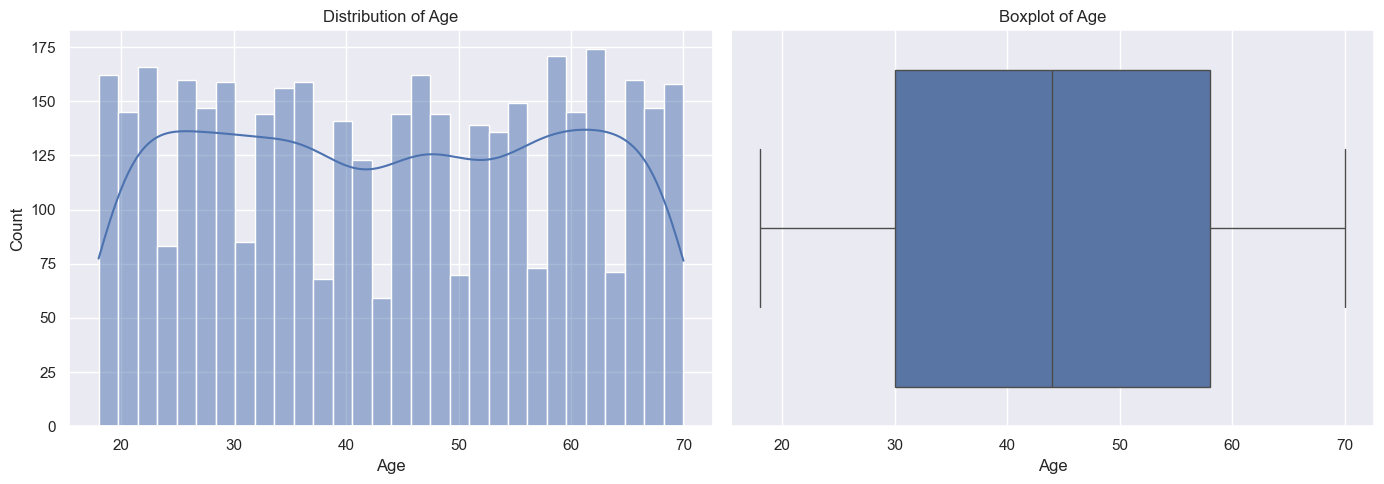

In [102]:
# Distribution: histogram + KDE, and boxplot for outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(X_train['age'], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Age")
axes[0].set_xlabel("Age")

sns.boxplot(x=X_train['age'], ax=axes[1])
axes[1].set_title("Boxplot of Age")
axes[1].set_xlabel("Age")

plt.tight_layout()
plt.show()

In [103]:
# IQR-based outlier check
q1, q3 = X_train['age'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

outliers = X_train[(X_train['age'] < lower) | (X_train['age'] > upper)]
print(f"IQR bounds: [{lower:.1f}, {upper:.1f}]")
print(f"Number of outliers: {len(outliers)}")

IQR bounds: [-12.0, 100.0]
Number of outliers: 0


#### 🔍 Takeaways: `age`

- **Uniform, not normal:** skewness ≈ 0.01 (symmetric) but kurtosis ≈ -1.25 (platykurtic — flatter and thinner-tailed than a bell curve). Combined with hard bounds at 18 and 70, `age` looks roughly uniformly sampled rather than clustered around a typical customer age.
- **No dominant cohort:** mean (43.7) and median (44) are nearly identical, and the IQR (30–57) spans almost half the full range. There's no age group that stands out as "the typical subscriber."
- **No outliers:** IQR bounds [-10.5, 97.5] comfortably contain the full 18–70 range, so no cleaning or capping is needed.
- **Modeling implication:** a flat marginal distribution means `age` is unlikely to be a strong standalone churn predictor by itself — a bivariate check (e.g., churn rate by age bucket, or `age` split by `churned`) is needed to see if it still carries signal once combined with the target.

#### Univariate analysis: `watch_hours`

In [104]:
# Summary statistics
watch_hours = X_train['watch_hours'].copy()
print(f"Description \n {watch_hours.describe()}")
print(f"Skewness: {watch_hours.skew():.4f}")
print(f"Kurtosis: {watch_hours.kurt():.4f}")

Description 
 count    4000.000000
mean       11.630010
std        12.014596
min         0.010000
25%         3.310000
50%         8.020000
75%        15.970000
max       110.400000
Name: watch_hours, dtype: float64
Skewness: 2.3220
Kurtosis: 8.4123


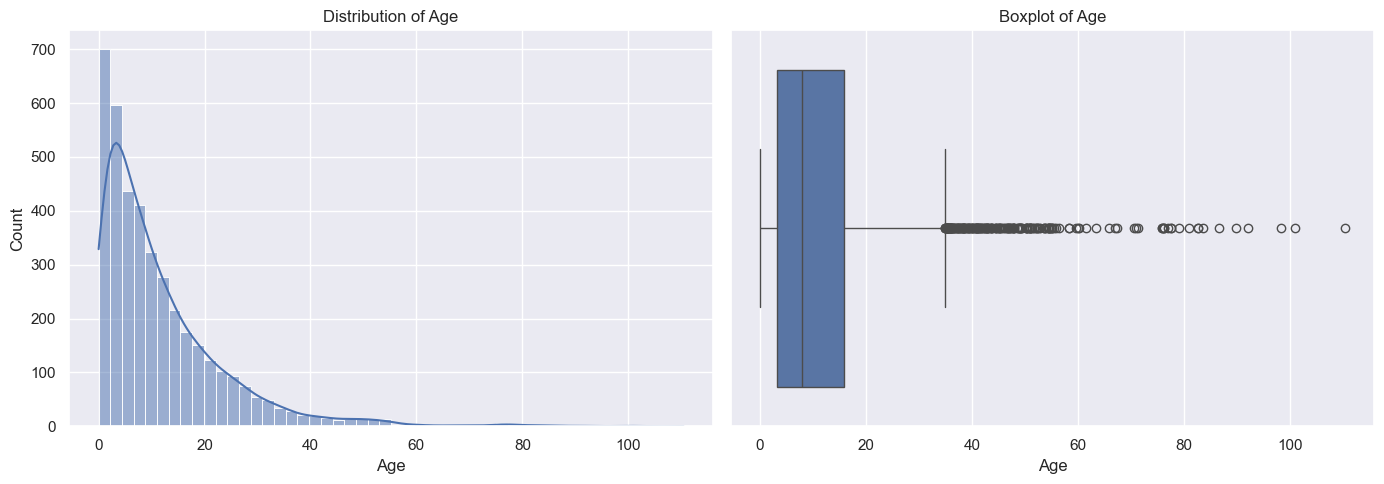

In [110]:
# Distribution: histogram + KDE, and boxplot for outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(watch_hours, bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Age")
axes[0].set_xlabel("Age")

sns.boxplot(x=watch_hours, ax=axes[1])
axes[1].set_title("Boxplot of Age")
axes[1].set_xlabel("Age")

plt.tight_layout()
plt.show()

In [111]:
# IQR-based outliers check
watch_hours_q1, watch_hours_q3 = watch_hours.quantile([0.25, 0.75])
watch_hours_iqr = watch_hours_q3 - watch_hours_q1
lower, upper = watch_hours_q1 - 1.5 * watch_hours_iqr, watch_hours_q3 + 1.5 * watch_hours_iqr

watch_hours_outliers = watch_hours[(watch_hours < lower) | (watch_hours > upper)]
print(f"IQR bounds: {lower:.1f}, {upper:.1f}")
print(f"Number of outliers: {len(watch_hours_outliers)}")

IQR bounds: -15.7, 35.0
Number of outliers: 191


#### 🔍 Takeaways: `watch_hours`

- **Strongly right-skewed:** skewness ≈ 2.32 and kurtosis ≈ 8.41 — the opposite of `age`'s flat, symmetric shape. Mean (11.63) sits well above the median (8.02), confirming a long right tail.
- **Most users watch moderately, a minority binges:** the IQR (3.31–15.97 hrs) covers the bulk of users, but the max reaches 110.4 hrs — consistent with the histogram's right-skew flagged earlier.
- **Outliers are heavy but plausible:** the IQR rule flags 191 of 4000 training rows (~4.8%) above the upper bound of 35.0 hrs (the lower bound is negative and not meaningful here, since watch hours can't go below 0). These look like genuine high-engagement "binge watcher" behavior rather than data errors, so they're candidates for a distinct segment rather than for removal/capping.
- **Modeling implication:** the skew is why train/test splitting was stratified on quantile bins of `watch_hours` (and `avg_watch_time_per_day`) rather than a plain random split. Tree-based models (Random Forest/XGBoost/LightGBM) can handle this skew natively, but a linear/logistic model would likely benefit from a log-transform given the skewness/kurtosis magnitude.